# Import

In [1]:
# importing
import numpy as np

from scipy import signal
import scipy as sp

import matplotlib.pyplot as plt
import matplotlib

# showing figures inline
%matplotlib inline

# plotting options 
font = {'size'   : 20}
plt.rc('font', **font)
plt.rc('text', usetex=True)

matplotlib.rc('figure', figsize=(18, 6) )

# Estimating ACF

In [2]:
########################
# acf estimator for acf
########################
def est_acf_onesided( y ):
    """
    estimates (biased) acf given a number of observations
    
    Remark: signal is assumed to be starting from 0 to length(y)-1
    
    IN: observations y
    OUT: estimated acf, indices 0...len(y)
    """
    N = np.size(y)
    r = np.zeros(N, dtype=complex)
    
    # loop lags of acf
    for k in np.arange(0,N):
        r[k] = np.sum( y[k:N] * np.conjugate(y[0:(N-k)]) ) 
        

    return  r / N

# Levinson-Durbin Algorithm

In [3]:
########################
# alg. of Levinson-Durbin
########################
def levinson_durbin( y, q_max):
    """
    estimates coefficients of an AR model given a number of observations
    
    Remark: signal is assumed to be starting from 0 to length(y)-1
    
    IN: observations y, max. AR degree
    OUT: AR coefficients
    """
    
    assert q_max < len( y ), 'Max. order has to be less than observation length!'
    
    # determining acf
    r = est_acf_onesided( y )
    
    # initialization
    theta = [ -r[1] / r[0] ]
    k = [ theta[ 0 ] ]
    noise = [ r[0] - abs( r[1] )**2 / r[0] ]
    
    # loop for AR orders
    for q in range( 1, q_max + 1 ):

            r_q_arrow = r[ : q ][::-1]
        
            # apply lev-dur iterations
            k.append( - ( r[ q ] + sum( r_q_arrow * theta[ -1 ] ) ) / noise[ -1 ] )

            noise.append( noise[ -1 ] * ( 1 - abs( k[ q ] )** 2 ) )

            if q > 1:
                theta_q_arrow = np.conjugate( np.flipud( theta[ q-1 ] ) )
                theta_new = np.append( theta[ q - 1 ], 0) + k[ q ] * np.append( theta_q_arrow, 1 )  
                
            else:
                theta_new = np.append( theta[ q - 1 ], 0) + k[ q ] * np.append( theta[ q - 1 ], 1 )  
                
            theta.append(  theta_new )

    return k, noise, theta
                            

# Generate Signals for Spectral Estimation

In [5]:
# parameters: number of signal samples
N = int( 1e3 )
N_vec = np.arange(0, N)

sigma2 = 1

# different signals to be analyzed      
choice = 6

#     
if choice==1: # AR spectrum out of the "spectrum" homepage
    a = [1, -2.2137, 2.9403, -2.1697, 0.9606]
    y = signal.lfilter([1], a, np.random.normal(0.0, 1.0, N))
    
elif choice==2: # just noise
    y = np.sqrt(sigma2) * np.random.normal(0.0, 1.0, N)
    
elif choice==3: # AR spectrum out of Kroschel
    b = [1]; a = [1 -1.372, 1.843, -1.238, .849]; sigma2 = .0032
    y = signal.lfilter(b, a, np.sqrt(sigma2)*Omega_1*N_vec)    
    
elif choice==4: # broad spectrum out of Kroschel
    b = [1, 0, 0, 0, -.5]; a = [1]; sigma2 = .44
    y = signal.lfilter(b, a, np.sqrt(sigma2)*Omega_1*N_vec)
    
elif choice==5: # two sinusoids with noise
    Omega_0 = 1.0; Omega_1 = 1.2; sigma2 = 2
    y = np.sin(Omega_0 * N_vec) + np.sin(Omega_1 * N_vec)  + np.sqrt(sigma2)*np.random.normal(0.0, 1.0, N)
    
elif choice==6: # two complex sinusoids with noise
    Omega_0 = 1.0; Omega_1 = 1.2; sigma2 = 2
    y = np.exp(1j*Omega_0 * N_vec) + np.exp(1j*Omega_1 * N_vec)  + np.sqrt(sigma2)*np.random.normal(0.0, 1.0, N)

# Spectral Estimation by Levinson-Durbin

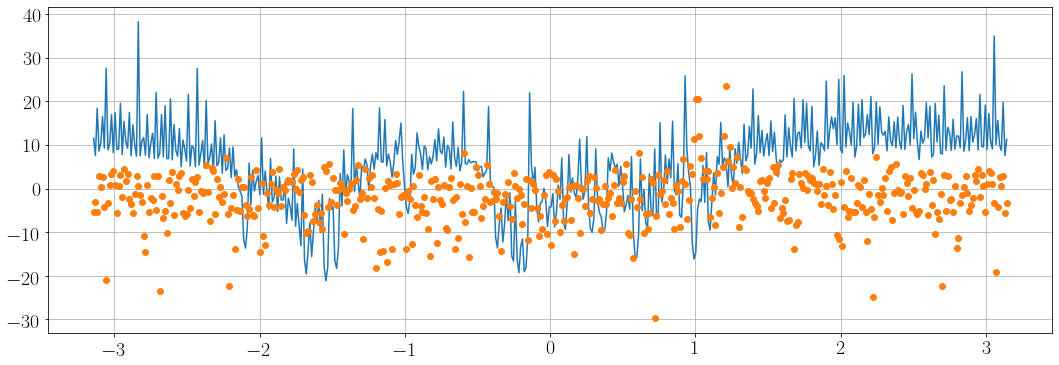

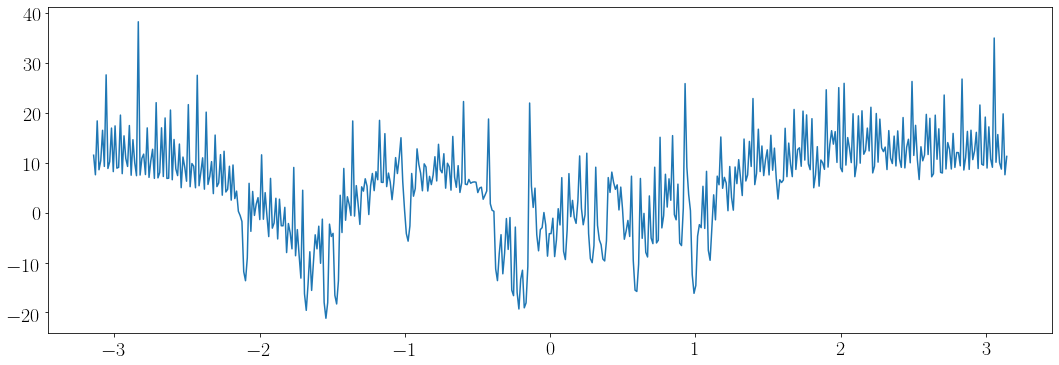

In [13]:
q_max = 200
k, noise, theta = levinson_durbin( y, q_max )

omega = np.linspace( -np.pi, np.pi, 512 )

cor = np.zeros(len(omega), dtype=complex)

# get frequency response    
for p in np.arange(0, q_max + 1):
    cor += theta[q_max][p]*np.exp(-1j*omega*p)

psd =  np.fft.fftshift( sigma2 / abs(per)**2 )

# plotting
plt.plot( omega, 10*np.log10(psd), label='period.')
plt.grid(1)


# fft-based periodogram for comparison
psd_fft = 1/len(y) * np.abs( np.fft.fft( y, len(omega) ) )**2
plt.plot(omega, 10*np.log10( np.fft.fftshift( psd_fft )),'o' )


# directly using YW
plt.figure()

# estimating the autocorrelation matrix    
R = np.zeros([ q_max,q_max], dtype=complex)
r_os = est_acf_onesided(y)

r_reverse = np.conjugate(r_os[::-1])     

r_2 = np.append(r_reverse[0:len(r_os)-1], r_os) 
for p in np.arange(0, q_max):
    R[p,:] = r_2[N-1-p : N-1-p+q_max ]

b = np.matrix(np.append(sigma2, np.zeros(q_max-1))).T

theta_2 = np.linalg.solve(R, b)
theta_2 = np.array(theta_2 / theta_2[0])

per_2 = np.zeros(len(omega), dtype=complex)

# get frequency response    
for p in np.arange(0, q_max):
    per_2 += theta_2[p]*np.exp(-1j*omega*p)

psd_2 =  np.fft.fftshift( sigma2 / abs(per)**2 )    

plt.plot( omega, 10*np.log10(psd_2))

